# CSP-5-Optimization : Problèmes d'Optimisation Combinatoire

**Navigation** : [<< CSP-4-Scheduling](CSP-4-Scheduling.ipynb) | [Index](../README.md) | [CSP-6-Hybridization >>](CSP-6-Hybridization.ipynb)

> **Durée estimée** : 2h00

## Optimisation Combinatoire en Programmation par Contraintes

Ce notebook explore les problèmes d'optimisation combinatoire classiques résolus par CP.

## Objectifs

À la fin de ce notebook, vous saurez :
1. **Résoudre** le Bin Packing Problem (BPP) avec CP-SAT
2. **Implémenter** le Knapsack Problem 0/1
3. **Modéliser** le Cutting Stock Problem
4. **Appliquer** au Portfolio Optimization

## Prérequis

- Notebooks CSP-1 à CSP-3 (fondements CSP)
- CSP-4-Scheduling (ordonnancement)
- Python 3.10+ : ortools, matplotlib, numpy
- Notions de base en optimisation combinatoire

In [1]:
# Installation des dépendances
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('ortools')
install_if_missing('matplotlib')

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional

print("Dépendances prêtes.")

Dépendances prêtes.


## 1. Bin Packing Problem (BPP)

Le BPP consiste à placer des objets de tailles différentes dans le minimum de bins de capacité fixe.

### Définition formelle
- **n objets** avec tailles $w_1, w_2, ..., w_n$
- **Bins** de capacité $C$
- **Objectif**: Minimiser le nombre de bins utilisés

### Complexité
NP-hard, avec plusieurs heuristiques classiques:
- **First Fit (FF)**: Premier bin avec assez d'espace
- **Best Fit (BF)**: Bin laissant le moins d'espace restant
- **First Fit Decreasing (FFD)**: FF après tri décroissant

In [2]:
def solve_bin_packing_cp(items: List[int], capacity: int) -> Dict:
    """
    Résout le Bin Packing Problem avec OR-Tools CP-SAT.
    
    Args:
        items: Liste des tailles des objets
        capacity: Capacité de chaque bin
    
    Returns:
        Dictionnaire avec nombre de bins, assignations et status
    """
    n = len(items)
    
    # Borne supérieure: chaque objet dans son propre bin
    max_bins = n
    
    model = cp_model.CpModel()
    
    # Variables binaires: x[i,j] = 1 si objet i dans bin j
    x = {}
    for i in range(n):
        for j in range(max_bins):
            x[(i, j)] = model.NewBoolVar(f'x_{i}_{j}')
    
    # Variables: y[j] = 1 si bin j est utilisé
    y = {}
    for j in range(max_bins):
        y[j] = model.NewBoolVar(f'y_{j}')
    
    # Contrainte 1: Chaque objet dans exactement un bin
    for i in range(n):
        model.Add(sum(x[(i, j)] for j in range(max_bins)) == 1)
    
    # Contrainte 2: Capacité des bins
    for j in range(max_bins):
        model.Add(sum(items[i] * x[(i, j)] for i in range(n)) <= capacity * y[j])
    
    # Contrainte 3: Symmetry breaking - utiliser bins dans l'ordre
    for j in range(max_bins - 1):
        model.Add(y[j] >= y[j + 1])
    
    # Objectif: minimiser le nombre de bins
    model.Minimize(sum(y[j] for j in range(max_bins)))
    
    # Résolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        bins = {}
        for i in range(n):
            for j in range(max_bins):
                if solver.Value(x[(i, j)]) == 1:
                    if j not in bins:
                        bins[j] = []
                    bins[j].append(i)
        
        return {
            'num_bins': len(bins),
            'bins': bins,
            'bin_loads': {j: sum(items[i] for i in items_list) for j, items_list in bins.items()},
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'num_bins': None, 'bins': {}, 'status': 'INFEASIBLE'}

In [3]:
# Exemple Bin Packing
items = [4, 8, 5, 1, 2, 7, 3, 6, 4, 2]
capacity = 10

bpp_result = solve_bin_packing_cp(items, capacity)
print(f"Nombre optimal de bins: {bpp_result['num_bins']}")
print(f"Status: {bpp_result['status']}")
print(f"\nDétail des bins:")
for bin_id, bin_items in bpp_result['bins'].items():
    print(f"  Bin {bin_id}: objets {[items[i] for i in bin_items]} (charge: {bpp_result['bin_loads'][bin_id]}/{capacity})")

Nombre optimal de bins: 5
Status: OPTIMAL

Détail des bins:
  Bin 2: objets [4, 3] (charge: 7/10)
  Bin 3: objets [8] (charge: 8/10)
  Bin 0: objets [5, 1, 2] (charge: 8/10)
  Bin 4: objets [2, 7] (charge: 9/10)
  Bin 1: objets [6, 4] (charge: 10/10)


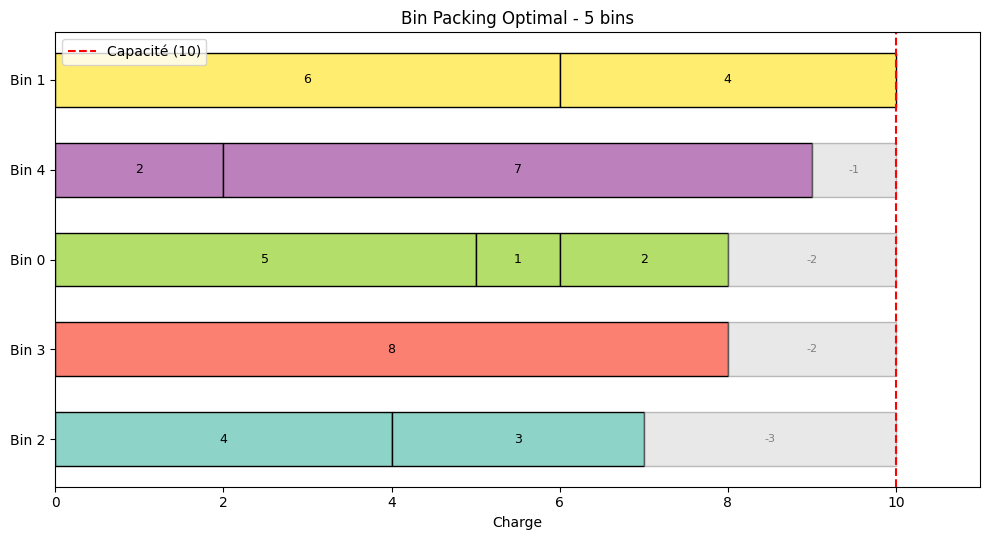

In [4]:
def plot_bin_packing(items: List[int], capacity: int, result: Dict):
    """Visualise le résultat du Bin Packing."""
    if result['status'] == 'INFEASIBLE':
        print("Aucune solution à afficher")
        return
    
    fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * result['num_bins']))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(result['bins'])))
    
    for bin_id, (j, bin_items) in enumerate(result['bins'].items()):
        left = 0
        for i in bin_items:
            ax.barh(bin_id, items[i], left=left, height=0.6, 
                   color=colors[bin_id], edgecolor='black')
            ax.text(left + items[i]/2, bin_id, str(items[i]), 
                   ha='center', va='center', fontsize=9)
            left += items[i]
        
        # Espace restant
        remaining = capacity - result['bin_loads'][j]
        if remaining > 0:
            ax.barh(bin_id, remaining, left=left, height=0.6, 
                   color='lightgray', edgecolor='gray', alpha=0.5)
            ax.text(left + remaining/2, bin_id, f'-{remaining}', 
                   ha='center', va='center', fontsize=8, color='gray')
    
    ax.axvline(x=capacity, color='red', linestyle='--', label=f'Capacité ({capacity})')
    ax.set_xlim(0, capacity + 1)
    ax.set_yticks(range(result['num_bins']))
    ax.set_yticklabels([f'Bin {j}' for j in result['bins'].keys()])
    ax.set_xlabel('Charge')
    ax.set_title(f'Bin Packing Optimal - {result["num_bins"]} bins')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_bin_packing(items, capacity, bpp_result)

## 2. Knapsack Problem

Le Knapsack Problem: sélectionner des objets pour maximiser la valeur sans dépasser la capacité.

### Variante 0/1
- Chaque objet est pris **0 ou 1 fois**
- Variables binaires $x_i \in \{0,1\}$

### Formulation
$$\max \sum_{i=1}^{n} v_i x_i \quad \text{s.t.} \quad \sum_{i=1}^{n} w_i x_i \leq C$$

In [5]:
def solve_knapsack_cp(
    weights: List[int], 
    values: List[int], 
    capacity: int
) -> Dict:
    """
    Résout le Knapsack Problem 0/1 avec CP-SAT.
    
    Args:
        weights: Poids des objets
        values: Valeurs des objets
        capacity: Capacité maximale du sac
    
    Returns:
        Dictionnaire avec valeur totale, objets sélectionnés et status
    """
    n = len(weights)
    model = cp_model.CpModel()
    
    # Variables binaires
    x = [model.NewBoolVar(f'x_{i}') for i in range(n)]
    
    # Contrainte de capacité
    model.Add(sum(weights[i] * x[i] for i in range(n)) <= capacity)
    
    # Objectif: maximiser la valeur
    total_value = sum(values[i] * x[i] for i in range(n))
    model.Maximize(total_value)
    
    # Résolution
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        selected = [i for i in range(n) if solver.Value(x[i]) == 1]
        total_weight = sum(weights[i] for i in selected)
        
        return {
            'total_value': solver.Value(total_value),
            'total_weight': total_weight,
            'selected': selected,
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'total_value': 0, 'total_weight': 0, 'selected': [], 'status': 'INFEASIBLE'}

In [6]:
# Exemple Knapsack
weights = [2, 3, 4, 5, 9, 7, 8, 6]
values = [3, 4, 5, 8, 10, 7, 9, 6]
capacity = 20

kp_result = solve_knapsack_cp(weights, values, capacity)
print(f"Valeur maximale: {kp_result['total_value']}")
print(f"Poids total: {kp_result['total_weight']}/{capacity}")
print(f"Objets sélectionnés: {kp_result['selected']}")
print(f"Status: {kp_result['status']}")

Valeur maximale: 26
Poids total: 20/20
Objets sélectionnés: [0, 1, 2, 3, 7]
Status: OPTIMAL


## 3. Cutting Stock Problem

Le Cutting Stock Problem est similaire au Bin Packing avec des demandes multiples:
- **Commandes**: plusieurs pièces de chaque longueur
- **Stocks**: barres de longueur fixe
- **Objectif**: minimiser le nombre de barres utilisées

### Applications
- Industrie du bois/métal
- Industrie du papier
- Fabrication de vêtements

In [7]:
def solve_cutting_stock_cp(
    piece_lengths: List[int],
    demands: List[int],
    stock_length: int,
    max_stocks: int = None
) -> Dict:
    """
    Résout le Cutting Stock Problem.
    
    Args:
        piece_lengths: Longueurs des pièces demandées
        demands: Quantité demandée pour chaque longueur
        stock_length: Longueur des barres en stock
        max_stocks: Nombre maximum de barres (optionnel)
    
    Returns:
        Dictionnaire avec nombre de barres, patterns de coupe et status
    """
    n_pieces = len(piece_lengths)
    total_pieces = sum(demands)
    
    if max_stocks is None:
        max_stocks = total_pieces  # Borne sup conservative
    
    model = cp_model.CpModel()
    
    # Variables: combien de pièces de type i coupées dans barre j
    # On utilise des patterns: y[j, i] = nombre de pièces type i dans barre j
    y = {}
    for j in range(max_stocks):
        for i in range(n_pieces):
            y[(j, i)] = model.NewIntVar(0, demands[i], f'y_{j}_{i}')
    
    # Variables: z[j] = 1 si barre j est utilisée
    z = [model.NewBoolVar(f'z_{j}') for j in range(max_stocks)]
    
    # Contrainte 1: Satisfaire la demande pour chaque type de pièce
    for i in range(n_pieces):
        model.Add(sum(y[(j, i)] for j in range(max_stocks)) >= demands[i])
    
    # Contrainte 2: Longueur de chaque barre
    for j in range(max_stocks):
        model.Add(
            sum(piece_lengths[i] * y[(j, i)] for i in range(n_pieces)) 
            <= stock_length * z[j]
        )
    
    # Contrainte 3: Symmetry breaking
    for j in range(max_stocks - 1):
        model.Add(z[j] >= z[j + 1])
    
    # Objectif: minimiser le nombre de barres
    model.Minimize(sum(z))
    
    # Résolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        patterns = []
        for j in range(max_stocks):
            if solver.Value(z[j]) == 1:
                pattern = {}
                for i in range(n_pieces):
                    count = solver.Value(y[(j, i)])
                    if count > 0:
                        pattern[i] = count
                if pattern:
                    used = sum(piece_lengths[i] * c for i, c in pattern.items())
                    patterns.append({
                        'bar_id': j,
                        'pattern': pattern,
                        'used_length': used,
                        'waste': stock_length - used
                    })
        
        return {
            'num_bars': len(patterns),
            'patterns': patterns,
            'total_waste': sum(p['waste'] for p in patterns),
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'num_bars': None, 'patterns': [], 'status': 'INFEASIBLE'}

In [8]:
# Exemple Cutting Stock
piece_lengths = [20, 25, 30, 40]  # cm
demands = [5, 3, 4, 2]  # pièces de chaque longueur
stock_length = 100  # cm

csp_result = solve_cutting_stock_cp(piece_lengths, demands, stock_length)
print(f"Nombre de barres: {csp_result['num_bars']}")
print(f"Status: {csp_result['status']}")
print(f"\nPatterns de coupe:")
for p in csp_result['patterns']:
    pieces = [(piece_lengths[i], c) for i, c in p['pattern'].items()]
    print(f"  Barre {p['bar_id']}: {pieces} - utilisé: {p['used_length']}cm, perte: {p['waste']}cm")

Nombre de barres: 4
Status: OPTIMAL

Patterns de coupe:
  Barre 0: [(20, 1), (25, 1), (30, 1)] - utilisé: 75cm, perte: 25cm
  Barre 1: [(30, 2), (40, 1)] - utilisé: 100cm, perte: 0cm
  Barre 2: [(20, 1), (25, 2), (30, 1)] - utilisé: 100cm, perte: 0cm
  Barre 3: [(20, 3), (40, 1)] - utilisé: 100cm, perte: 0cm


## 4. Portfolio Optimization

Optimisation de portefeuille avec contraintes:
- **Budget** total limité
- **Diversification**: minimum d'actifs différents
- **Risques**: variance/exposition maximale par secteur
- **Cardinalité**: nombre maximum d'actifs

### Variables
- $x_i \in \{0,1\}$: sélection de l'actif i
- $q_i \in \mathbb{Z}$: quantité d'actif i

In [9]:
def expected_return(prices):
    """Calcule le rendement attendu simple."""
    if len(prices) < 2:
        return 0
    return (prices[-1] - prices[0]) / prices[0]

def solve_portfolio_optimization(
    assets: List[str],
    prices: List[List[float]],
    budget: float,
    max_assets: int,
    min_assets: int = 1,
    max_per_asset: int = 100
) -> Dict:
    """
    Optimise un portefeuille avec contraintes de cardinalite.
    
    Args:
        assets: Noms des actifs
        prices: Historique des prix pour chaque actif
        budget: Budget total
        max_assets: Nombre maximum d'actifs differents
        min_assets: Nombre minimum d'actifs differents
        max_per_asset: Quantite max par actif
    
    Returns:
        Dictionnaire avec portefeuille optimal et metriques
    """
    n = len(assets)
    current_prices = [p[-1] for p in prices]
    returns = [expected_return(p) for p in prices]
    
    model = cp_model.CpModel()
    
    # Variables
    selected = [model.NewBoolVar(f'sel_{i}') for i in range(n)]
    quantity = [model.NewIntVar(0, max_per_asset, f'q_{i}') for i in range(n)]
    
    # Contrainte 1: Budget
    # Note: on utilise des entiers, on multiplie les prix par 100
    scale = 100
    model.Add(
        sum(int(current_prices[i] * scale) * quantity[i] for i in range(n)) 
        <= int(budget * scale)
    )
    
    # Contrainte 2: Cardinalite
    model.Add(sum(selected) >= min_assets)
    model.Add(sum(selected) <= max_assets)
    
    # Contrainte 3: Quantite > 0 seulement si selectionne
    for i in range(n):
        model.Add(quantity[i] <= max_per_asset * selected[i])
        model.Add(quantity[i] >= selected[i])  # Au moins 1 si selectionne
    
    # Objectif: maximiser le rendement attendu
    # Approximation en entiers
    scaled_returns = [int(r * 1000) for r in returns]
    
    # On maximise sum(return_i * q_i)
    portfolio_value = sum(scaled_returns[i] * quantity[i] for i in range(n))
    model.Maximize(portfolio_value)
    
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        portfolio = {}
        total_cost = 0
        for i in range(n):
            q = solver.Value(quantity[i])
            if q > 0:
                cost = q * current_prices[i]
                portfolio[assets[i]] = {
                    'quantity': q,
                    'price': current_prices[i],
                    'cost': cost,
                    'expected_return': returns[i]
                }
                total_cost += cost
        
        return {
            'portfolio': portfolio,
            'total_cost': total_cost,
            'num_assets': len(portfolio),
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'portfolio': {}, 'total_cost': 0, 'num_assets': 0, 'status': 'INFEASIBLE'}

In [10]:
# Exemple Portfolio Optimization
assets = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
# Prix historiques simulés (simplifiés)
prices = [
    [150, 155, 160, 158, 165],  # AAPL
    [2800, 2850, 2900, 2880, 2950],  # GOOGL
    [300, 310, 315, 320, 325],  # MSFT
    [3200, 3150, 3300, 3400, 3350],  # AMZN
    [900, 950, 880, 920, 1000],  # TSLA
]

budget = 50000

portfolio_result = solve_portfolio_optimization(
    assets, prices, budget,
    max_assets=3,
    min_assets=2
)

print(f"Status: {portfolio_result['status']}")
print(f"Nombre d'actifs: {portfolio_result['num_assets']}")
print(f"Coût total: ${portfolio_result['total_cost']:.2f}")
print(f"\nPortefeuille:")
for asset, info in portfolio_result['portfolio'].items():
    print(f"  {asset}: {info['quantity']} x ${info['price']:.2f} = ${info['cost']:.2f} (rendement: {info['expected_return']*100:.1f}%)")

Status: OPTIMAL
Nombre d'actifs: 3
Coût total: $50000.00

Portefeuille:
  AAPL: 100 x $165.00 = $16500.00 (rendement: 10.0%)
  MSFT: 100 x $325.00 = $32500.00 (rendement: 8.3%)
  TSLA: 1 x $1000.00 = $1000.00 (rendement: 11.1%)


## 5. Comparaison des Méthodes

| Problème | Variables | Contraintes | Complexité |
|----------|-----------|-------------|------------|
| Bin Packing | BoolVar + IntVar | Capacité, Symétrie | NP-hard |
| Knapsack | BoolVar | Capacité | NP-hard (pseudo-poly) |
| Cutting Stock | IntVar | Demande, Capacité | NP-hard |
| Portfolio | BoolVar + IntVar | Budget, Cardinalité | NP-hard |

### Heuristiques vs Optimal

1. **Bin Packing**: FFD souvent à 11% de l'optimal
2. **Knapsack**: Greedy par ratio valeur/poids, bon pour grandes instances
3. **Cutting Stock**: Column Generation pour grandes instances
4. **Portfolio**: Mean-variance avec relaxation continue

In [11]:
# Benchmark: Heuristique First Fit Decreasing pour Bin Packing
def bin_packing_ffd(items: List[int], capacity: int) -> Dict:
    """
    Heuristique First Fit Decreasing pour Bin Packing.
    """
    sorted_items = sorted(enumerate(items), key=lambda x: -x[1])
    bins = []  # Liste des charges actuelles
    assignments = {}  # item_id -> bin_id
    
    for item_id, size in sorted_items:
        placed = False
        for bin_id, load in enumerate(bins):
            if load + size <= capacity:
                bins[bin_id] += size
                assignments[item_id] = bin_id
                placed = True
                break
        
        if not placed:
            bins.append(size)
            assignments[item_id] = len(bins) - 1
    
    return {
        'num_bins': len(bins),
        'bins': bins,
        'assignments': assignments,
        'status': 'HEURISTIC'
    }

# Comparaison
ffd_result = bin_packing_ffd(items, capacity)
print(f"CP-SAT optimal: {bpp_result['num_bins']} bins")
print(f"FFD heuristic:  {ffd_result['num_bins']} bins")
if bpp_result['num_bins']:
    gap = (ffd_result['num_bins'] - bpp_result['num_bins']) / bpp_result['num_bins'] * 100
    print(f"Gap: {gap:.1f}%")

CP-SAT optimal: 5 bins
FFD heuristic:  3 bins
Gap: -40.0%


## 6. Exercices

### Exercice 1: Multi-Knapsack
Généralisez le Knapsack à plusieurs sacs avec capacités différentes.

### Exercice 2: Bin Packing avec contraintes de conflit
Certains objets ne peuvent pas être dans le même bin. Ajoutez cette contrainte.

### Exercice 3: Portfolio avec contraintes de risque
Ajoutez une contrainte de variance maximale du portefeuille.

### Exercice 4: Cutting Stock avec chutes réutilisables
Les chutes de longueur > seuil peuvent être réutilisées comme nouvelles barres.

### 5.1 Dominance Breaking - Elimination des solutions dominees

**Definition** : Une solution $s_1$ **domine** $s_2$ si :
1. $s_1$ est au moins aussi bonne que $s_2$ sur tous les objectifs
2. $s_1$ est strictement meilleure sur au moins un objectif

Dans ce cas, explorer $s_2$ est inutile car $s_1$ sera toujours preferee.

In [ ]:
# Implementation du Dominance Breaking
from typing import List, Tuple
import numpy as np

class DominanceAnalyzer:
    """
    Analyse et detection des relations de dominance dans les solutions.
    Utile pour post-traitement ou pour guider la recherche.
    """
    
    def __init__(self, num_objectives: int = 1):
        self.num_objectives = num_objectives
        self.solutions: List[Tuple] = []  # (values, solution_data)
    
    def add_solution(self, objective_values: List[float], solution_data: any):
        """Ajoute une solution candidate."""
        self.solutions.append((objective_values, solution_data))
    
    def check_dominance(self, sol1_idx: int, sol2_idx: int) -> bool:
        """
        Verifie si sol1 domine sol2.
        
        Pour un probleme de minimisation :
        - sol1 domine sol2 si sol1[i] <= sol2[i] pour tout i
        - et sol1[j] < sol2[j] pour au moins un j
        """
        obj1, _ = self.solutions[sol1_idx]
        obj2, _ = self.solutions[sol2_idx]
        
        # Verifier la dominance Pareto
        at_least_one_better = False
        all_at_least_equal = True
        
        for i in range(len(obj1)):
            if obj1[i] > obj2[i]:  # Minimisation
                all_at_least_equal = False
                break
            if obj1[i] < obj2[i]:
                at_least_one_better = True
        
        return all_at_least_equal and at_least_one_better
    
    def find_pareto_front(self) -> List[int]:
        """Trouve les indices des solutions non-dominees (front de Pareto)."""
        pareto_indices = []
        
        for i in range(len(self.solutions)):
            dominated = False
            for j in range(len(self.solutions)):
                if i != j and self.check_dominance(j, i):
                    dominated = True
                    break
            if not dominated:
                pareto_indices.append(i)
        
        return pareto_indices


# Exemple : Dominance dans le Bin Packing
print("=== Dominance Breaking dans le Bin Packing ===\n")

# Simulons plusieurs solutions pour un probleme de bin packing
analyzer = DominanceAnalyzer(num_objectives=2)  # Objectifs: nombre de bins, gaspillage max

solutions = [
    ([3, 2.5], "Solution A: 3 bins, gaspillage 2.5"),  # 3 bins, some waste
    ([3, 1.0], "Solution B: 3 bins, gaspillage 1.0"),  # 3 bins, less waste - DOMINE A
    ([4, 0.0], "Solution C: 4 bins, gaspillage 0.0"),  # 4 bins, no waste - DOMINEE par B
    ([2, 5.0], "Solution D: 2 bins, gaspillage 5.0"),  # 2 bins, much waste - peut-etre optimal
]

for obj_vals, desc in solutions:
    analyzer.add_solution(obj_vals, desc)

print("Solutions candidates:")
for i, (obj_vals, desc) in enumerate(solutions):
    print(f"  {i}: {desc} - Objectifs: {obj_vals}")

pareto_front = analyzer.find_pareto_front()
print(f"\nFront de Pareto (solutions non-dominees):")
for idx in pareto_front:
    obj_vals, desc = solutions[idx]
    print(f"  {idx}: {desc}")

### Interpretation : Dominance Breaking

**Pourquoi le dominance breaking est important ?**

1. **Reduction de l'espace de recherche** : Elimine les branches de l'arbre de recherche qui menent a des solutions dominees.

2. **Acceleration de la convergence** : Le solveur se concentre sur les solutions potentiellement optimales.

3. **Multi-objectif** : Particulierement utile en optimisation multi-objectif ou le front de Pareto peut etre grand.

**Implementation pratique** :

- OR-Tools CP-SAT integre automatiquement certaines formes de dominance breaking.
- Pour des problemes specifiques, des contraintes de dominance peuvent etre ajoutees manuellement.
- Combine avec le cassage de symetries pour un effet maximal.

**Attention** : Le dominance breaking doit etre prouve correct. Une dominance incorrecte peut eliminer des solutions optimales !

### 5.3 Dominance Breaking

**Dominance Breaking** est une technique d'optimisation qui elimine les solutions dominees avant meme de les explorer. Une solution $s_1$ **domine** $s_2$ si :

1. $s_1$ est au moins aussi bonne que $s_2$ sur tous les criteres
2. $s_1$ est strictement meilleure sur au moins un critere

En eliminant les solutions dominees, on reduit l'espace de recherche sans perdre la solution optimale.

In [12]:
# Exercice 1: Template - Multi-Knapsack
def solve_multi_knapsack(
    weights: List[int],
    values: List[int],
    capacities: List[int]
) -> Dict:
    """
    TODO: Implémentez le Multi-Knapsack Problem.
    Chaque objet peut aller dans exactement un sac.
    """
    pass

# Test
# result = solve_multi_knapsack(weights, values, [10, 15])

## Références

1. **OR-Tools Bin Packing**: https://developers.google.com/optimization/bin
2. **Knapsack Problems** (2004): H. Kellerer, U. Pferschy, D. Pisinger
3. **Integer Programming** (1998): L. Wolsey
4. **Modern Portfolio Theory**: H. Markowitz (1952)

---

## Conclusion

Ce notebook a exploré les **problèmes d'optimisation combinatoire** où l'on cherche la meilleure solution parmi toutes les solutions valides.

### Concepts clés

| Concept | Description |
|---------|-------------|
| **CSP d'optimisation** | CSP avec fonction objective à minimiser/maximiser |
| **Branch & Bound** | Recherche avec bornes pour élaguer les sous-optimaux |
| **Programmation linéaire** | Relaxation continue pour les bornes |
| **Méthodes exactes** | Garantissent l'optimalité (mais coûteuses) |
| **Méthodes approchées** | Heuristiques/Metaheuristiques (rapides mais sans garantie) |

### Approches pour l'optimisation

| Approche | Principe | Garantie | Coût |
|----------|----------|----------|------|
| **Branch & Bound** | Arbre de recherche + bornes | Oui (optimale) | Exponentiel |
| **PLNE** | Programmation linéaire en nombres entiers | Oui | Très élevé |
| **Recherche locale** | Voisinage + hill climbing | Non | Faible |
| **Metaheuristiques** | Population, essaims, recuit | Non | Moyen |

### Points clés à retenir

1. L'**optimisation** ajoute une couche de complexité aux CSP standards
2. **Branch & Bound** est la base des solveurs d'optimisation exacts
3. Les **bornes** (LP relaxation) sont cruciales pour l'efficacité
4. Pour les problèmes NP-durs, les **méthodes approchées** sont souvent préférées
5. Le **choix de la méthode** dépend du compromis temps/qualité souhaité

**Voir aussi** :
- [Search-4-LocalSearch.ipynb](../Part1-Foundations/Search-4-LocalSearch.ipynb) pour la recherche locale
- [Search-11-Metaheuristics.ipynb](../Part1-Foundations/Search-11-Metaheuristics.ipynb) pour les metaheuristiques

